In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [4]:
# =====================================================
# Load Train-Test Dataset (CSV)
# =====================================================



X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")

y_train = pd.read_csv("y_train.csv").squeeze()
y_test = pd.read_csv("y_test.csv").squeeze()

print("Train/Test Shapes")
print("-" * 30)
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)





Train/Test Shapes
------------------------------
X_train: (692, 34)
X_test : (174, 34)
y_train: (692,)
y_test : (174,)


In [5]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [6]:
from sklearn.preprocessing import StandardScaler

numeric_features = [
    "Company",
    "Product_Weight"
]

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Fit scaler ONLY on training data
X_train_scaled[numeric_features] = scaler.fit_transform(
    X_train[numeric_features]
)

# Apply the same scaler to test data
X_test_scaled[numeric_features] = scaler.transform(
    X_test[numeric_features]
)

StandardScaler is applied only to the continuous numerical features
(Company and Product_Weight) as value are not in range. Linear models are sensitive to feature
scale, whereas one-hot encoded binary features do not require scaling.



After one-hot encoding, you'll have around 60–80 features (depending on the categories).

Your dataset has 866 samples.

This is not a high-dimensional dataset. PCA is generally more useful when you have hundreds or thousands of correlated numerical features (e.g., images, gene expression data, text embeddings). With your structured tabular data, PCA may:

reduce interpretability,
mix one-hot encoded categorical features into principal components,
make it harder to explain the model in your dissertation,
and may not improve prediction performance.

Most tree-based models you're planning to use (Random Forest, XGBoost, CatBoost) do not benefit from PCA.

In [7]:

# Model Performance Table
# =====================================================

results = pd.DataFrame(
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2_Original",
        "R2_Log"
    ]
)

# Model 1 : Linear Regression

In [8]:

# Model 1 : Linear Regression
# =====================================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import PredictionErrorDisplay

In [9]:
# Initialize model
lr = LinearRegression()
lr.fit(
    X_train_scaled,
    y_train_log
)

LinearRegression()

In [10]:
# Prediction on log scale
y_pred_log = lr.predict(X_test_scaled)

# Convert predictions back to original PCF scale
y_pred = np.expm1(y_pred_log)


In [11]:


print("y_test")
print("NaN:", np.isnan(y_test).sum())
print("Inf:", np.isinf(y_test).sum())
print("Max:", np.max(y_test))

print("\ny_pred_log")
print("NaN:", np.isnan(y_pred_log).sum())
print("Inf:", np.isinf(y_pred_log).sum())
print("Max:", np.max(y_pred_log))

print("\ny_pred")
print("NaN:", np.isnan(y_pred).sum())
print("Inf:", np.isinf(y_pred).sum())
print("Max:", np.max(y_pred))

y_test
NaN: 0
Inf: 0
Max: 99075.0

y_pred_log
NaN: 0
Inf: 0
Max: 15.207609523019073

y_pred
NaN: 0
Inf: 0
Max: 4023284.9331674087


In [12]:
score = lr.score(X_test, y_test)
score

0.13190297752812186

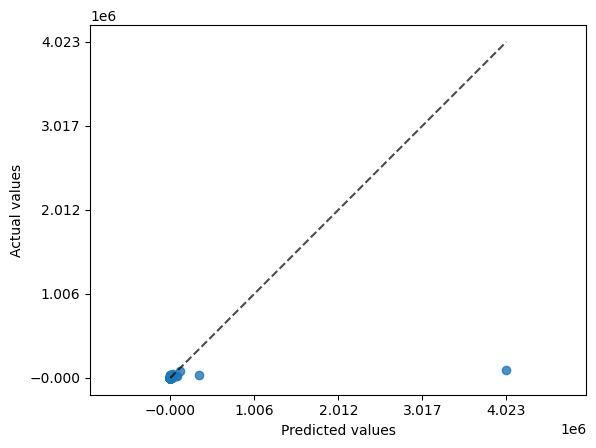

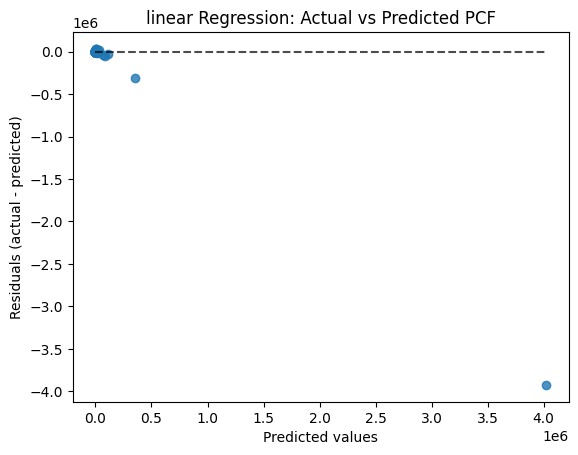

In [13]:

PredictionErrorDisplay.from_predictions(
    y_test,
    y_pred,
    kind="actual_vs_predicted"
).plot()

plt.title("linear Regression: Actual vs Predicted PCF")
plt.show()

In [14]:
print("Maximum log prediction:", y_pred_log.max())
print("Maximum original prediction:", y_pred.max())

idx = np.argmax(y_pred)

print("\nProblematic prediction:")
print("Actual:", y_test.iloc[idx])
print("Log prediction:", y_pred_log[idx])
print("Original prediction:", y_pred[idx])

Maximum log prediction: 15.207609523019073
Maximum original prediction: 4023284.9331674087

Problematic prediction:
Actual: 99075.0
Log prediction: 15.207609523019073
Original prediction: 4023284.9331674087


Linear Regression performs reasonably on the log-transformed target (R² = 0.642) but performs poorly on the original PCF scale because errors in log predictions can become very large when transformed back using expm1().

In [15]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2_original = r2_score(
    y_test,
    y_pred
)

r2_log = r2_score(
    y_test_log,
    y_pred_log
)

In [16]:
print("=" * 60)
print("Linear Regression (Baseline)")
print("=" * 60)

print(f"MAE (Original Scale)       : {mae:,.2f}")
print(f"RMSE (Original Scale)      : {rmse:,.2f}")
print(f"R² (Original Scale)        : {r2_original:.4f}")
print(f"R² (Log-transformed Scale) : {r2_log:.4f}")

Linear Regression (Baseline)
MAE (Original Scale)       : 26,910.97
RMSE (Original Scale)      : 298,528.55
R² (Original Scale)        : -586.3506
R² (Log-transformed Scale) : 0.6335


R² compares your model against simply predicting the mean of y_test.

One prediction is:

Actual       = 99,075
Predicted    = 1,469,145
Error        ≈ -1,370,070

That enormous error gets squared when calculating R² and RMSE.

That's why you have:

RMSE = 104,438
R²   = -70.886

The single extreme prediction has a very large influence.

But why is MAE only 10,777?

Because MAE doesn't square the errors. Most of your observations appear to have much smaller errors, while that one extreme prediction is dominating the squared-error metrics.

Your log R² tells a different story

You have:

R² (Log scale) = 0.642

That's actually reasonably meaningful. It means the Linear Regression model explains about 64.2% of the variance in the log-transformed PCF target.

The problem occurs when you convert:

y_pred_log

back to:

y_pred = np.expm1(y_pred_log)

because the exponential transformation magnifies large log-scale predictions.

So your interpretation should be:

Linear Regression achieved an R² of 0.642 on the log-transformed target but a negative R² of −70.886 on the original scale. The negative original-scale R² is largely driven by extreme prediction errors after transforming the predictions back from the logarithmic scale, including a prediction of approximately 1.47 million for an actual PCF of 99,075.

In [17]:
results.loc[len(results)] = [
    "Linear Regression (Baseline)",
    mae,
    rmse,
    r2_original,
    r2_log
]

results

,Model,MAE,RMSE,R2_Original,R2_Log
0,Linear Regression (Baseline),26910.969061,298528.547167,-586.350559,0.633542


Yes — **now your calculations are on the correct scales**. However, the model's **original-scale performance is still poor**, while its log-scale performance is reasonable.

Your results:

| Metric      |       Result | Interpretation  |
| ----------- | -----------: | --------------- |
| MAE         |    10,777.89 | High            |
| RMSE        |   104,438.21 | Very high       |
| R² Original | **-70.8860** | Very poor       |
| R² Log      |   **0.6420** | Reasonably good |

### The important part

Your `R² Log = 0.6420` means the Linear Regression explains about **64.2% of the variance in the log-transformed PCF target**.

But:

```text
R² Original = -70.886
```

means that when you convert predictions back to the original PCF scale, the model performs very poorly.

This is **possible and not necessarily a coding error**, especially because your PCF target is extremely right-skewed:

```text
Skewness = 17.63
```

You have some very large PCF values, so a few bad predictions can make the original-scale RMSE and R² extremely poor.

### Your next step

Since you are comparing models, I would **keep both metrics**:

```text
R² (Log-transformed Scale)
R² (Original Scale)
MAE (Original Scale)
RMSE (Original Scale)
```

Then compare Linear Regression with Ridge, XGBoost, CatBoost, etc.

Based on the results you showed earlier, **XGBoost is performing much better than Linear Regression** on both scales.

For example, your earlier XGBoost result was approximately:

```text
XGBoost:
MAE Original       = 1,924.84
RMSE Original      = 8,445.93
R² Original        = 0.5299
R² Log             = 0.9392
```

compared with Linear Regression:

```text
Linear Regression:
MAE Original       = 10,777.89
RMSE Original      = 104,438.21
R² Original        = -70.8860
R² Log             = 0.6420
```

So **the Linear Regression result is now technically valid, but it is a weak model for your dataset**.

One thing I would check before moving on is **why the Linear Regression's original-scale predictions are so extreme**. A residual/predicted-vs-actual plot would help diagnose that.


Just be transparent in your methodology that scaling was performed after the train/test split and before cross-validation.

Your test set remains completely untouched.

Ridge Regression

ridge = Ridge(
    alpha=1.0,
    random_state=42
)

In [18]:
from sklearn.linear_model import Ridge

ridge = Ridge(
    alpha=1.0,
    random_state=42
)

In [19]:
ridge.fit(
    X_train_scaled,
    y_train_log
)

Ridge(random_state=42)

In [20]:
y_pred_log = ridge.predict(
    X_test_scaled
)

y_pred = np.expm1(
    y_pred_log
)

In [21]:
score = ridge.score(X_test, y_test_log)
score

-558070.1820098277

In [22]:
mae = mean_absolute_error(y_test,y_pre)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
r2_original = r2_score(y_test,y_pred)
r2_log = r2_score(y_test_log,y_pred_log)

In [23]:
print("=" * 60)
print("Ridge Regression")
print("=" * 60)

print(f"RMSE (Original Scale)      : {rmse:,.2f}")
print(f"MAE (Original Scale)       : {mae:,.2f}")
print(f"R² (Original Scale)        : {r2_original:.4f}")
print(f"R² (Log-transformed Scale) : {r2_log:.4f}")

Ridge Regression
RMSE (Original Scale)      : 270,464.59
MAE (Original Scale)       : 25,143.44
R² (Original Scale)        : -481.1104
R² (Log-transformed Scale) : 0.6423


In [24]:
results.loc[len(results)] = [
    "Ridge Regression (baseline)",
    rmse,
    mae,
    r2_original,
    r2_log
]

results

,Model,MAE,RMSE,R2_Original,R2_Log
0,Linear Regression (Baseline),26910.969061,298528.547167,-586.350559,0.633542
1,Ridge Regression (baseline),270464.586615,25143.437665,-481.110366,0.642319


In [25]:
# Grid Search for Ridge Regression
param_grid = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    Ridge(),
    param_grid=param_grid,
    n_iter=20,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train_log)

print("Best Parameters:", grid.best_params_)
print("Best CV Score :", grid.best_score_)

Best Parameters: {'alpha': 1}
Best CV Score : 0.7052247497060397


In [26]:
best_ridge = grid.best_estimator_

In [27]:
y_pred_log = best_ridge.predict(X_test_scaled)

y_pred = np.expm1(y_pred_log)

In [28]:
score = best_ridge.score(X_test, y_test_log)
score

-558070.1820098277

In [29]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2_original = r2_score(y_test, y_pred)

r2_log = r2_score(y_test_log, y_pred_log)

In [30]:
print("=" * 60)
print("Ridge Regression(Gridsearch CV)")
print("=" * 60)

print(f"MAE (Original Scale)       : {mae:,.2f}")
print(f"RMSE (Original Scale)      : {rmse:,.2f}")
print(f"R² (Original Scale)        : {r2_original:.4f}")
print(f"R² (Log-transformed Scale) : {r2_log:.4f}")

Ridge Regression(Gridsearch CV)
MAE (Original Scale)       : 25,143.44
RMSE (Original Scale)      : 270,464.59
R² (Original Scale)        : -481.1104
R² (Log-transformed Scale) : 0.6423


In [31]:
results.loc[len(results)] = [
    "Ridge Regression (Gridsearch CV)",
    mae,
    rmse,
    r2_original,
    r2_log
]
results

,Model,MAE,RMSE,R2_Original,R2_Log
0,Linear Regression (Baseline),26910.969061,298528.547167,-586.350559,0.633542
1,Ridge Regression (baseline),270464.586615,25143.437665,-481.110366,0.642319
2,Ridge Regression (Gridsearch CV),25143.437665,270464.586615,-481.110366,0.642319


In [ ]:
# Randomsearch Cv for Ridge regression
param_grid = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}
random_search = RandomizedSearchCV(
    estimator=Ridge(),
    param_grid=param_grid,
    n_iter=20,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

random_search.fit(
    X_train_scaled,
    y_train_log
)

print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)


Model to be work with: Support Vector Regression (SVR)

K-Nearest Neighbors (KNN)

Version 2 – Unscaled Dataset
Use this version for tree-based models, including:

Random Forest

XGBoost

LightGBM

CatBoost

# SVR

In [32]:
from sklearn.svm import SVR

In [33]:
svr = SVR()

svr.fit(X_train_scaled, y_train_log)

SVR()

In [34]:
y_pred_log = svr.predict(X_test_scaled)

y_pred = np.expm1(y_pred_log)

In [35]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2_original = r2_score(y_test, y_pred)

r2_log = r2_score(y_test_log, y_pred_log)



In [36]:
print("="*60)
print("SVR (Baseline)")
print("="*60)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Original: {r2_original:.4f}")
print(f"R² Log: {r2_log:.4f}")

SVR (Baseline)
MAE : 3960.78
RMSE: 12911.85
R² Original: -0.0988
R² Log: -0.0006


In [37]:
results.loc[len(results)] = [
    "SVR Base Linee",
    mae,
    rmse,
    r2_original,
    r2_log
]

results

,Model,MAE,RMSE,R2_Original,R2_Log
0,Linear Regression (Baseline),26910.969061,298528.547167,-586.350559,0.633542
1,Ridge Regression (baseline),270464.586615,25143.437665,-481.110366,0.642319
2,Ridge Regression (Gridsearch CV),25143.437665,270464.586615,-481.110366,0.642319
3,SVR Base Linee,3960.776459,12911.847378,-0.098759,-0.000648


In [38]:
#GridSearch CV

param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", "auto", 0.01, 0.1],
    "kernel": ["rbf", "linear"]
}

grid = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid,
    cv=5,
    n_iter = 20
    scoring="r2",
    n_jobs=-1
)

grid.fit(
    X_train_scaled,
    y_train_log
)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Best CV Score: 0.8124113353400432


In [39]:
best_svr_grid = grid.best_estimator_

y_pred_log = best_svr_grid.predict(X_test_scaled)

y_pred = np.expm1(y_pred_log)

In [40]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2_original = r2_score(y_test, y_pred)

r2_log = r2_score(y_test_log, y_pred_log)

In [41]:
print("="*60)
print("SVR (GridSearch CV)")
print("="*60)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Original: {r2_original:.4f}")
print(f"R² Log: {r2_log:.4f}")

SVR (GridSearch CV)
MAE : 2242.22
RMSE: 8661.83
R² Original: 0.5055
R² Log: 0.7927


In [42]:
results.loc[len(results)] = [
    "SVR (Gridsearch CV)",
    mae,
    rmse,
    r2_original,
    r2_log
]

results

,Model,MAE,RMSE,R2_Original,R2_Log
0,Linear Regression (Baseline),26910.969061,298528.547167,-586.350559,0.633542
1,Ridge Regression (baseline),270464.586615,25143.437665,-481.110366,0.642319
2,Ridge Regression (Gridsearch CV),25143.437665,270464.586615,-481.110366,0.642319
3,SVR Base Linee,3960.776459,12911.847378,-0.098759,-0.000648
4,SVR (Gridsearch CV),2242.223611,8661.834986,0.505524,0.792745


In [ ]:
#RandomSearch CV

param_dist = {
    "C": [0.1, 1, 10, 50, 100, 500],
    "gamma": ["scale", "auto", 0.001, 0.01, 0.1, 1],
    "kernel": ["rbf", "linear", "poly"]
}

random_search = RandomizedSearchCV(
    estimator=SVR(),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

random_search.fit(
    X_train_scaled,
    y_train_log
)

print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)

In [ ]:
best_svr_random = random_search.best_estimator_

y_pred_log = best_svr_random.predict(X_test_scaled)

y_pred = np.expm1(y_pred_log)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2_original = r2_score(y_test, y_pred)

r2_log = r2_score(y_test_log, y_pred_log)

In [ ]:
print("="*60)
print("SVR (Randomsearch CV)")
print("="*60)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Original: {r2_original:.4f}")
print(f"R² Log: {r2_log:.4f}")

In [ ]:
results.loc[len(results)] = [
    "SVR (Randomsearch CV)",
    mae,
    rmse,
    r2_original,
    r2_log
]

results

Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor



In [ ]:
rf = RandomForestRegressor(
    random_state=42
)

In [ ]:
rf.fit(
    X_train,
    y_train_log
)

In [ ]:
y_pred_log = rf.predict(
    X_test
)

In [ ]:
y_pred = np.expm1(
    y_pred_log
)
y_pred

In [ ]:
score = rf.score(X_test, y_test)
score

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2_original = r2_score(y_test, y_pred)

r2_log = r2_score(y_test_log, y_pred_log)

In [ ]:
print("=" * 60)
print("Random forest (baseline)")
print("=" * 60)

print(f"MAE (Original Scale)       : {mae:,.2f}")
print(f"RMSE (Original Scale)      : {rmse:,.2f}")
print(f"R² (Original Scale)        : {r2_original:.4f}")
print(f"R² (Log-transformed Scale) : {r2_log:.4f}")

In [ ]:
results.loc[len(results)] = [
    "Ridge Regression (Random Search CV)",
    mae,
    rmse,
    r2_original,
    r2_log
]
results

In [ ]:
#GridSearch CV for Random Forest

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20,None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4,6]
}

grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_iter = 20
    n_jobs=-1
)

grid.fit(
    X_train,
    y_train_log
)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

In [ ]:
best_rf = grid.best_estimator_

y_pred_log = best_rf.predict(X_test)

y_pred = np.expm1(y_pred_log)

In [ ]:
score = best_rf.score(X_test, y_test_log)

print(score)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2_original = r2_score(y_test, y_pred)

r2_log = r2_score(y_test_log, y_pred_log)

In [ ]:
print("=" * 60)
print("Random Search (Gridsearch CV)")
print("=" * 60)

print(f"MAE (Original Scale)       : {mae:,.2f}")
print(f"RMSE (Original Scale)      : {rmse:,.2f}")
print(f"R² (Original Scale)        : {r2_original:.4f}")
print(f"R² (Log-transformed Scale) : {r2_log:.4f}")

In [ ]:
results.loc[len(results)] = [
    "Ridge Regression (Gridsearch CV)",
    mae,
    rmse,
    r2_original,
    r2_log
]
results

In [ ]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

In [ ]:
import matplotlib.pyplot as plt

importance.plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(10,5),
    legend=False
)

plt.title("Random Forest Feature Importance")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

In [ ]:
# Randomized Search for Random Forest

param_dist = {
    "n_estimators": [100, 200, 300, 400, 500],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=30,    # Test 30 random combinations
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train_log)

print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)

In [ ]:
best_rf = random_search . best_estimator_

y_pred_log = best_rf.predict(X_test)

y_pred = np.expm1(y_pred_log)

In [ ]:
score = best_rf.score(X_test, y_test_log)

print(f"score:{score}")

In [ ]:


mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2_original = r2_score(y_test, y_pred)

r2_log = r2_score(y_test_log, y_pred_log)

In [ ]:
print("=" * 60)
print("Random forest(Random Search CV)")
print("=" * 60)

print(f"MAE (Original Scale)       : {mae:,.2f}")
print(f"RMSE (Original Scale)      : {rmse:,.2f}")
print(f"R² (Original Scale)        : {r2_original:.4f}")
print(f"R² (Log-transformed Scale) : {r2_log:.4f}")

In [ ]:
results.loc[len(results)] = [
    "Ridge Regression (Random Search CV)",
    mae,
    rmse,
    r2_original,
    r2_log
]
results

# XG Boost


In [ ]:
%pip install xgboost

In [ ]:

from xgboost import XGBRegressor



In [ ]:
xgb = XGBRegressor(
    random_state=42,
    objective="reg:squarederror"
)

In [ ]:
xgb.fit(
    X_train,
    y_train_log
)

In [ ]:
y_pred_log = xgb.predict(X_test)

y_pred = np.expm1(y_pred_log)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt( mean_squared_error(y_test, y_pred))

r2_original = r2_score( y_test, y_pred)

r2_log = r2_score(y_test_log,y_pred_log)

In [ ]:
print("=" * 60)
print("XGBoost (Baseline)")
print("=" * 60)

print(f"MAE (Original Scale)       : {mae:.2f}")
print(f"RMSE (Original Scale)      : {rmse:.2f}")
print(f"R² (Original Scale)        : {r2_original:.4f}")
print(f"R² (Log-transformed Scale) : {r2_log:.4f}")

In [ ]:
results.loc[len(results)] = [
    "XGBoost (Baseline)",
    mae,
    rmse,
    r2_original,
    r2_log
]

results

In [ ]:
best_xgb = random_search.best_estimator_

y_pred_log = best_xgb.predict(X_test)

y_pred = np.expm1(y_pred_log)

In [ ]:
#randomized Search for XGBoost

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [3, 5, 7, 10],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1, 3, 5]
}

random_search = RandomizedSearchCV(
    estimator=XGBRegressor(
        random_state=42,
        objective="reg:squarederror"
    ),
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

random_search.fit(
    X_train,
    y_train_log
)

print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2_original = r2_score(y_test, y_pred)
r2_log = r2_score(y_test_log, y_pred_log)


In [ ]:
print("=" * 60)
print("XGBoost (Random Search CV)")
print("=" * 60)

print(f"MAE (Original Scale)       : {mae:.2f}")
print(f"RMSE (Original Scale)      : {rmse:.2f}")
print(f"R² (Original Scale)        : {r2_original:.4f}")
print(f"R² (Log-transformed Scale) : {r2_log:.4f}")

In [ ]:

results.loc[len(results)] = [
    "XGBoost (Tuned)",
    mae,
    rmse,
    r2_original,
    r2_log
]

In [ ]:
#grid search for XGBoost
param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [3, 5, 7],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}
grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid.fit(
    X_train,
    y_train_log
)

In [ ]:
print("Best Parameters:")
print(grid.best_params_)

print("\nBest CV Score:")
print(grid.best_score_)

In [ ]:
best_xgb = grid.best_estimator_
y_pred_log = best_xgb.predict(X_test)

y_pred = np.expm1(y_pred_log)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2_original = r2_score(y_test, y_pred)

r2_log = r2_score(y_test_log, y_pred_log)

In [ ]:
print("=" * 60)
print("XGBoost (Gridsearch CV)")
print("=" * 60)

print(f"MAE (Original Scale)       : {mae:.2f}")
print(f"RMSE (Original Scale)      : {rmse:.2f}")
print(f"R² (Original Scale)        : {r2_original:.4f}")
print(f"R² (Log-transformed Scale) : {r2_log:.4f}")

In [ ]:
results.loc[len(results)] = [
    "XGBoost (GridSearchCV)",
    mae,
    rmse,
    r2_original,
    r2_log
]

results

# CAT Boost

In [ ]:
%pip install catboost

In [ ]:
from catboost import CatBoostRegressor

In [ ]:
cat = CatBoostRegressor(
    random_seed=42,
    verbose=0
)

In [ ]:
cat.fit(
    X_train,
    y_train_log
)

In [ ]:
y_pred_log = cat.predict(X_test)

y_pred = np.expm1(y_pred_log)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt( mean_squared_error(y_test, y_pred))

r2_original = r2_score(y_test, y_pred)

r2_log = r2_score(y_test_log,y_pred_log)

In [ ]:
print("=" * 60)
print("CatBoost (Baseline)")
print("=" * 60)

print(f"MAE (Original Scale)       : {mae:.2f}")
print(f"RMSE (Original Scale)      : {rmse:.2f}")
print(f"R² (Original Scale)        : {r2_original:.4f}")
print(f"R² (Log-transformed Scale) : {r2_log:.4f}")

In [ ]:
results.loc[len(results)] = [
    "CatBoost (Baseline)",
    mae,
    rmse,
    r2_original,
    r2_log
]

results

In [ ]:
# Grid Search for CatBoost

param_grid = {
    "iterations": [100, 200, 300],
    "depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1]
}

grid = GridSearchCV(
    estimator=CatBoostRegressor(
        random_seed=42,
        verbose=0
    ),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(
    X_train,
    y_train_log
)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

In [ ]:
best_cat = grid.best_estimator_

y_pred_log = best_cat.predict(X_test)

y_pred = np.expm1(y_pred_log)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2_original = r2_score(y_test, y_pred)

r2_log = r2_score(y_test_log, y_pred_log)

In [ ]:
print("=" * 60)
print("CatBoost (Gridsearch CV")
print("=" * 60)

print(f"MAE (Original Scale)       : {mae:.2f}")
print(f"RMSE (Original Scale)      : {rmse:.2f}")
print(f"R² (Original Scale)        : {r2_original:.4f}")
print(f"R² (Log-transformed Scale) : {r2_log:.4f}")

In [ ]:
results.loc[len(results)] = [
    "CatBoost (GridSearchCV)",
    mae,
    rmse,
    r2_original,
    r2_log
]

results

In [ ]:
#Randomized Search for CatBoost

param_dist = {
    "iterations": [100, 200, 300, 500],
    "depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "l2_leaf_reg": [1, 3, 5, 7, 9],
    "subsample": [0.8, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=cat,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(
    X_train,
    y_train_log
)

In [ ]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV Score:")
print(random_search.best_score_)

In [ ]:
best_cat = random_search.best_estimator_

In [ ]:
y_pred_log = best_cat.predict(X_test)

y_pred = np.expm1(y_pred_log)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2_original = r2_score(y_test, y_pred)

r2_log = r2_score(y_test_log, y_pred_log)

In [ ]:
print("=" * 60)
print("CatBoost (Randomized Search CV)")
print("=" * 60)

print(f"MAE (Original Scale)       : {mae:.2f}")
print(f"RMSE (Original Scale)      : {rmse:.2f}")
print(f"R² (Original Scale)        : {r2_original:.4f}")
print(f"R² (Log-transformed Scale) : {r2_log:.4f}")

In [ ]:
results.loc[len(results)] = [
    "CatBoost (Randomized Search CV)",
    mae,
    rmse,
    r2_original,
    r2_log
]

results